In [1]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec


# Run scan_L_A.py to generate the results for Fig2.ipynb


In [ ]:
# Run scan_L_A.py to generate the results for Fig2.ipynb

# Create an empty DataFrame with the specified headers
df = pd.DataFrame(columns=['L', 'A', 'NC1', 'PR', 'order'])


result_files = glob.glob('./results/sweep_S_A_seed/*')

for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    L = data_dict['C'].L
    S = data_dict['C'].length_corridors[0]
    if L ==0:
        continue
    A = data_dict['C'].max_move
    if data_dict['accuracy_l'][-1] < 0.99:
        print(f"A={A}, L={L}, accuracy={data_dict['accuracy_l'][-1]}")
        plt.plot(data_dict['accuracy_l'])
        plt.show()
    action_taken = data_dict['action_taken']
    data_dict['X'] = data_dict['X'][abs(action_taken) <= 1]
    data_dict['y'] = data_dict['y'][abs(action_taken) <= 1]
    data_dict['hidden_states'][-1] = data_dict['hidden_states'][-1][abs(action_taken) <= 1]
    data_dict['loc_y'] = data_dict['loc_y'][abs(action_taken) <= 1]
    NC1 = calc_NC1_from_data_dict(data_dict)
    PR = calc_PR(data_dict['hidden_states'][-1].cpu().numpy())
    order = get_order(data_dict)

    df = pd.concat([df, pd.DataFrame([{
        'S': S,
        'A': A,
        'NC1': NC1,
        'PR': PR,
        'order': order
    }])], ignore_index=True)



  0%|                                                     | 0/3645 [00:00<?, ?it/s]

/tmp/ipykernel_614943/2207037686.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{
100%|██████████████████████████████████████████| 3645/3645 [23:48<00:00,  2.55it/s]


In [5]:
# Set global matplotlib formatting for ICLR paper compatibility
# Set global font to Times New Roman

mpl.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,  # TrueType fonts for compatibility
    'ps.fonttype': 42,
    'text.usetex': False,  # Set to True if you want LaTeX rendering and have it installed
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'serif'],
})

import seaborn as sns
sns.set_context("paper")
sns.set_style("whitegrid")


In [13]:
df

,L,A,NC1,margins,order,S,PR,L_num,A_num,S_num
0,NaN,8,0.000032,NaN,0.972520,19.0,1.615925,NaN,8,20.0
1,NaN,7,0.000052,NaN,0.972463,17.0,1.421936,NaN,7,18.0
2,NaN,4,0.000037,NaN,0.445688,38.0,3.427922,NaN,4,39.0
3,NaN,4,0.000023,NaN,0.938701,18.0,1.401591,NaN,4,19.0
4,NaN,8,0.000064,NaN,0.963344,18.0,1.830721,NaN,8,19.0
...,...,...,...,...,...,...,...,...,...,...
3640,NaN,1,0.000023,NaN,0.007116,34.0,4.264380,NaN,1,35.0
3641,NaN,3,0.000047,NaN,0.776584,30.0,3.025354,NaN,3,31.0
3642,NaN,8,0.000195,NaN,0.979895,38.0,2.276857,NaN,8,39.0
3643,NaN,6,0.000238,NaN,0.717561,45.0,3.255728,NaN,6,46.0


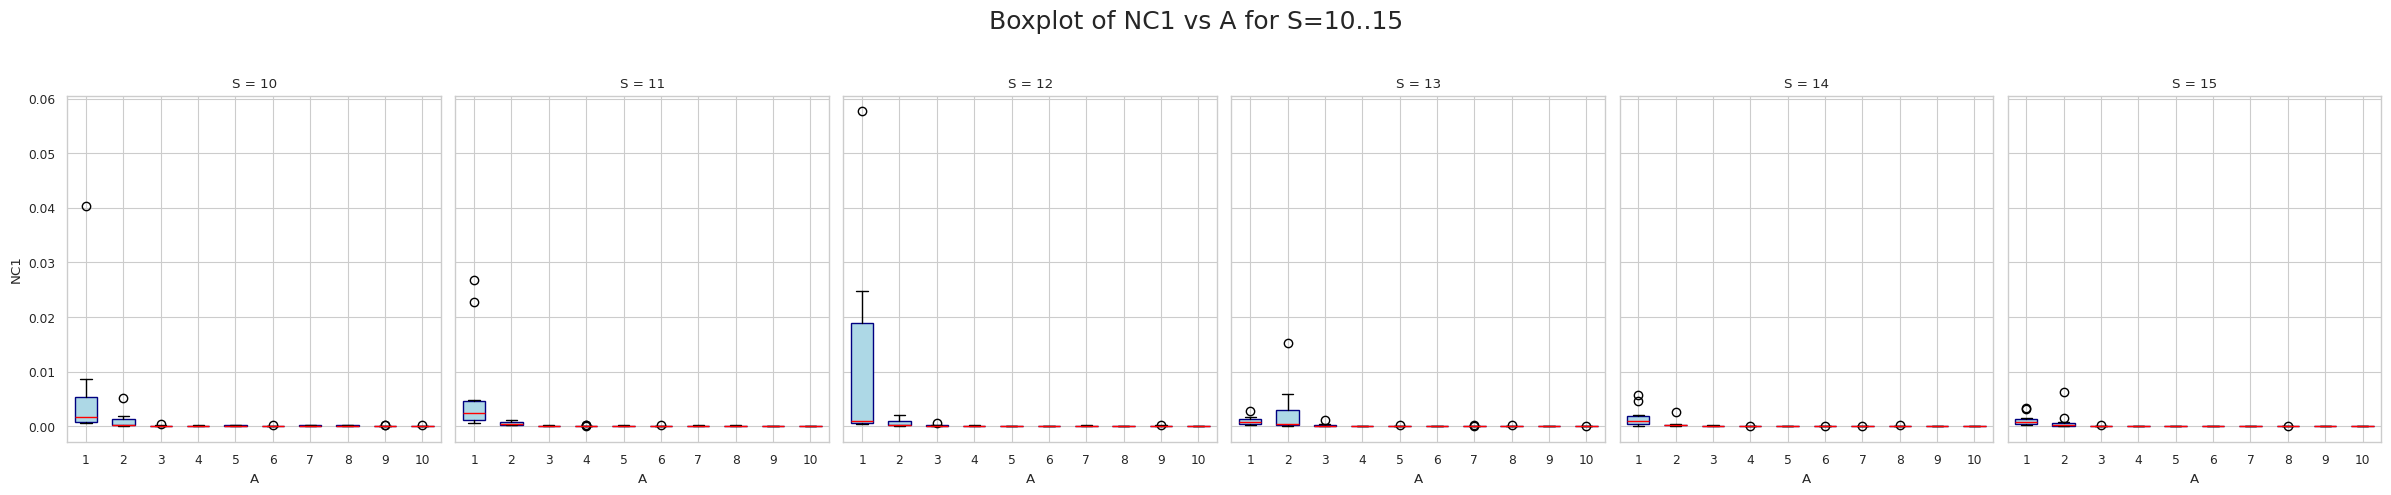

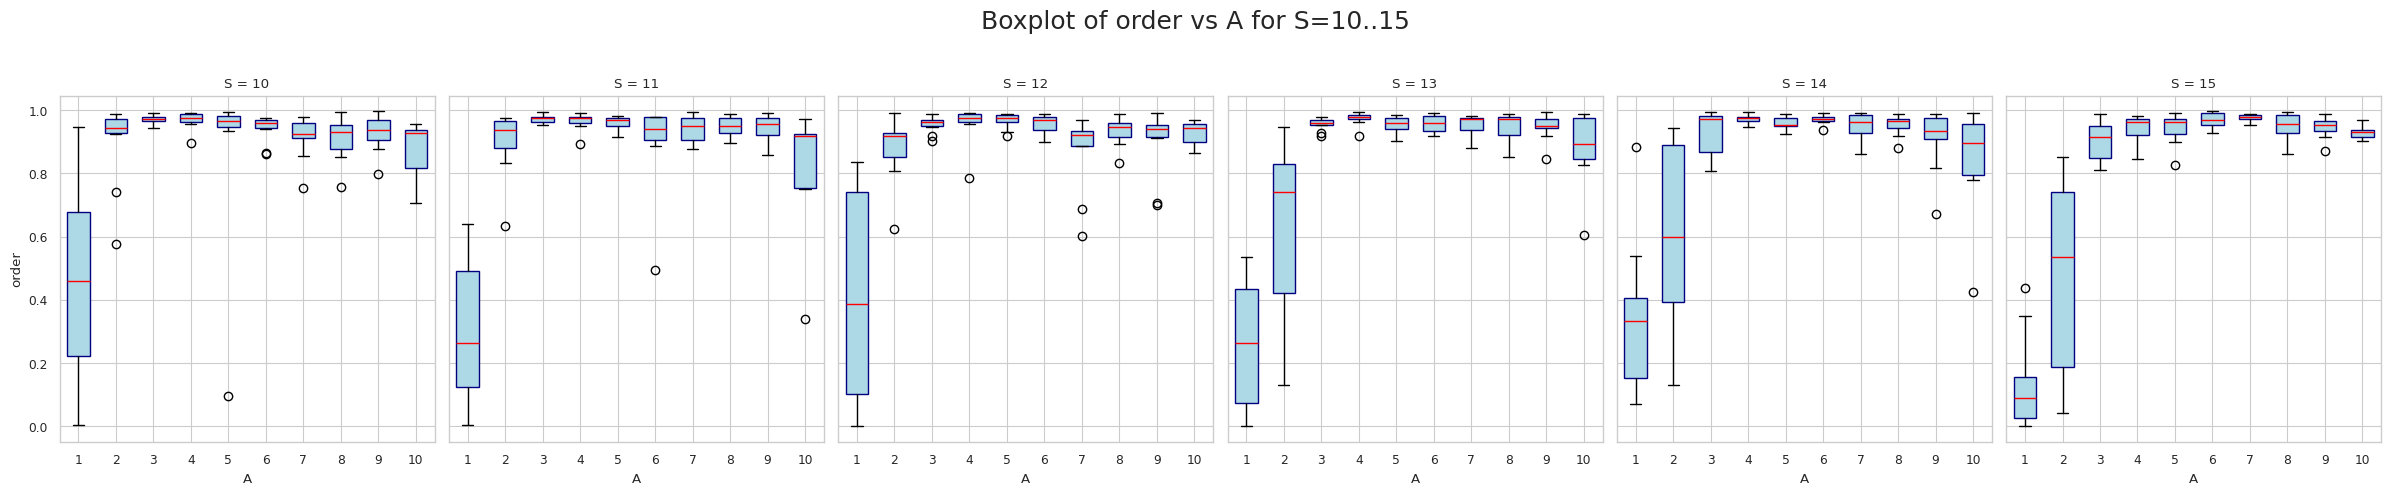

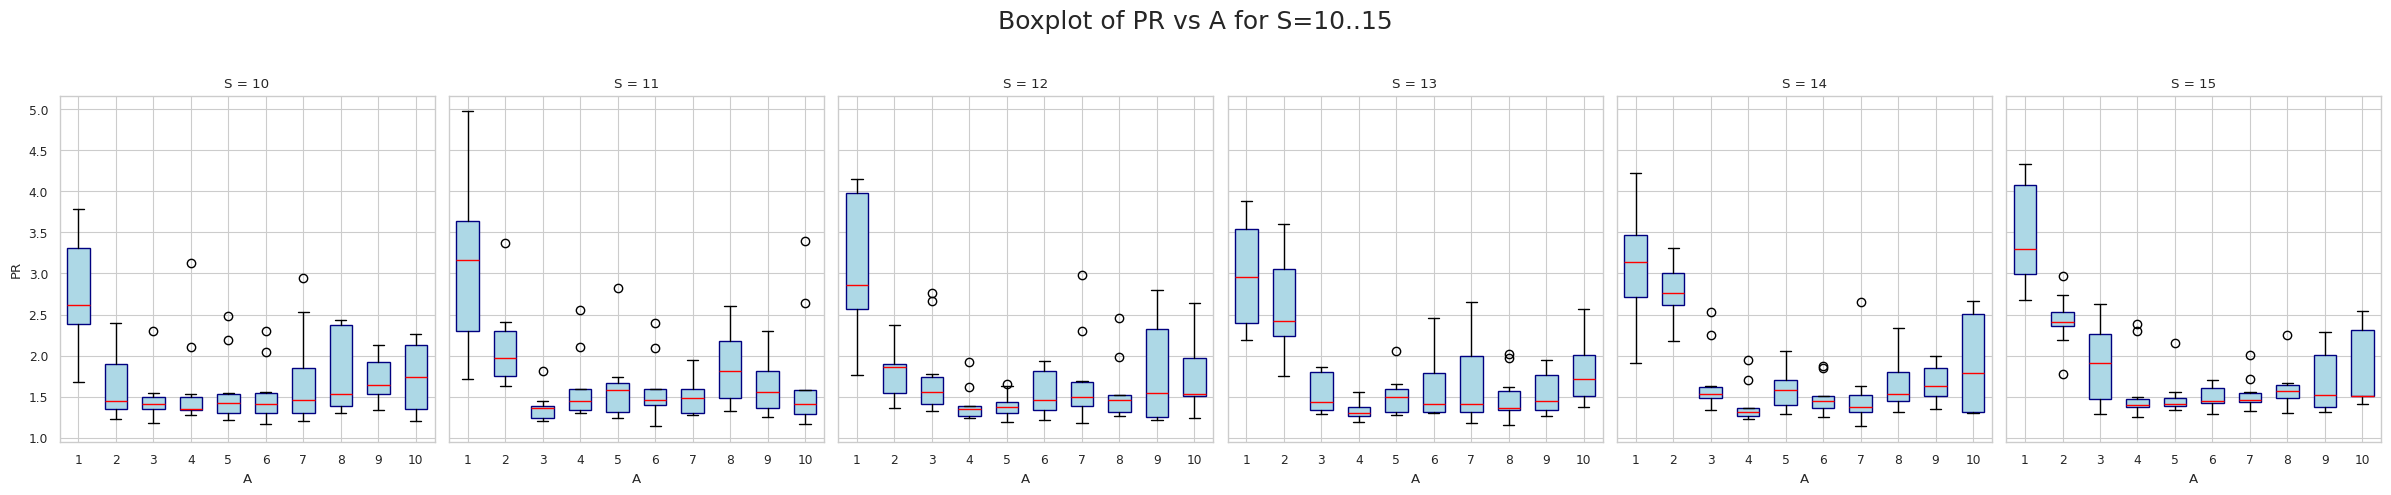

In [19]:
import matplotlib.pyplot as plt

# We'll use the DataFrame `df` from cell 5, which should have columns:
# 'A', 'S', 'NC1', 'margins', 'order', 'PR', etc.
# We'll plot for S in 10..15 (inclusive), for each metric.

metrics = ['NC1', 'order', 'PR']
S_values = list(range(10, 16))
A_col = 'A'
S_col = 'S'

for metric in metrics:
    fig, axes = plt.subplots(1, len(S_values), figsize=(4*len(S_values), 5), sharey=True)
    for i, S_val in enumerate(S_values):
        ax = axes[i] if len(S_values) > 1 else axes
        # Select rows with S == S_val
        df_S = df[df[S_col] == S_val]
        # Drop NaN in A or metric
        df_S = df_S[[A_col, metric]].dropna()
        # Sort A for consistent x-axis
        A_sorted = sorted(df_S[A_col].unique())
        # Prepare data for boxplot: list of arrays, one per A
        data = [df_S[df_S[A_col] == a][metric].values for a in A_sorted]
        ax.boxplot(data, positions=A_sorted, widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red'))
        ax.set_title(f"S = {S_val}")
        ax.set_xlabel("A")
        if i == 0:
            ax.set_ylabel(metric)
        ax.set_xticks(A_sorted)
    fig.suptitle(f"Boxplot of {metric} vs A for S=10..15", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [17]:
pivot_order

S_num,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,...,41.0,42.0,43.0,44.0,45.0,46.0,47.0,48.0,49.0,50.0
A_num,,,,,,,,,,,,,,,,,,,,,
1,0.451301,0.306803,0.407310,0.251332,0.341585,0.132640,0.226608,0.356805,0.201735,0.215185,...,0.146280,0.080837,0.139761,0.081283,0.129893,0.118038,0.142474,0.082711,0.103195,0.106869
2,0.896458,0.900661,0.881584,0.630583,0.618905,0.478559,0.497339,0.385136,0.421468,0.435212,...,0.180409,0.109701,0.194406,0.163071,0.078661,0.196654,0.264935,0.103520,0.142244,0.261511
3,0.969960,0.973485,0.954407,0.956136,0.925956,0.902107,0.903828,0.812394,0.669346,0.869830,...,0.345900,0.163617,0.267324,0.243812,0.208502,0.176275,0.205393,0.184463,0.174865,0.066687
4,0.968699,0.964936,0.958196,0.973664,0.972503,0.944076,0.966300,0.965574,0.912287,0.947598,...,0.339796,0.245202,0.277206,0.396966,0.413275,0.291419,0.454593,0.261719,0.293061,0.184424
5,0.880980,0.960949,0.966518,0.953444,0.959759,0.942965,0.953154,0.977398,0.965905,0.964311,...,0.413939,0.557798,0.513235,0.551943,0.404848,0.529341,0.270031,0.362126,0.394818,0.235768
6,0.941469,0.900088,0.954465,0.957673,0.970284,0.969233,0.958509,0.971344,0.961940,0.961717,...,0.575940,0.563199,0.647960,0.675447,0.493016,0.519429,0.537231,0.616927,0.430330,0.387932
7,0.914064,0.942363,0.868233,0.952225,0.949316,0.976637,0.949375,0.960813,0.972069,0.947526,...,0.670698,0.830799,0.784897,0.789833,0.688291,0.725583,0.575722,0.587497,0.524854,0.483656
8,0.911666,0.948927,0.932199,0.946959,0.952742,0.945124,0.951727,0.953588,0.939362,0.954820,...,0.903919,0.872982,0.904807,0.742713,0.763115,0.706337,0.565053,0.676958,0.574309,0.778800
9,0.927659,0.942885,0.899940,0.947552,0.909046,0.946273,0.938625,0.938331,0.942025,0.958025,...,0.955940,0.823895,0.930615,0.876863,0.939971,0.953875,0.782476,0.707245,0.890489,0.831581


100%|██████████| 190/190 [00:00<00:00, 312.62it/s]


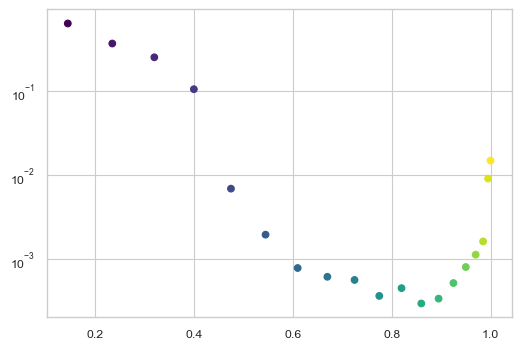

In [26]:

# Create an empty DataFrame with the specified headers

result_files = glob.glob('../results/sweep_L_A/*')

A_l = []
Coverage_l = []
NC1_l = []
for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    L = data_dict['C'].L
    if L != 5:
        continue
    A = data_dict['C'].max_move
    S = data_dict['C'].length_corridors[0]
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    coverage = (X.T@y)[:S,:S].mean()
    NC1 = calc_NC1_from_data_dict(data_dict)
    A_l.append(A)
    Coverage_l.append(coverage)
    NC1_l.append(NC1)
plt.scatter(Coverage_l, NC1_l, c=A_l, cmap='viridis')
plt.yscale('log')
plt.show()

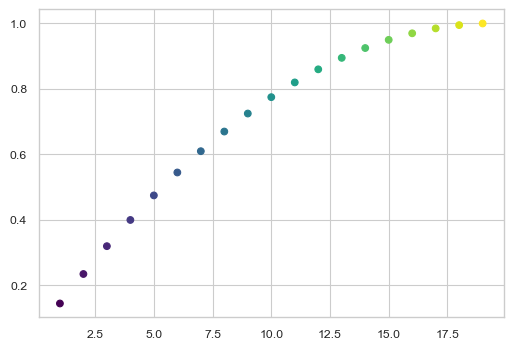

In [27]:

plt.scatter(A_l, Coverage_l, c=A_l, cmap='viridis')
# plt.yscale('log')
plt.show()